## Librerías

In [381]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler


## Carga del dataset

In [382]:
df = pd.read_csv("../data/raw/heart.csv")

## EDA

### Exploración de variables y estructura general

In [383]:
df.head()

,age,sex,chest_pain_type,resting_blood_pressure,cholestoral,fasting_blood_sugar,rest_ecg,Max_heart_rate,exercise_induced_angina,oldpeak,slope,vessels_colored_by_flourosopy,thalassemia,target
0,52,Male,Typical angina,125,212,Lower than 120 mg/ml,ST-T wave abnormality,168,No,1.0,Downsloping,Two,Reversable Defect,0
1,53,Male,Typical angina,140,203,Greater than 120 mg/ml,Normal,155,Yes,3.1,Upsloping,Zero,Reversable Defect,0
2,70,Male,Typical angina,145,174,Lower than 120 mg/ml,ST-T wave abnormality,125,Yes,2.6,Upsloping,Zero,Reversable Defect,0
3,61,Male,Typical angina,148,203,Lower than 120 mg/ml,ST-T wave abnormality,161,No,0.0,Downsloping,One,Reversable Defect,0
4,62,Female,Typical angina,138,294,Greater than 120 mg/ml,ST-T wave abnormality,106,No,1.9,Flat,Three,Fixed Defect,0


In [384]:
df.describe()

,age,resting_blood_pressure,cholestoral,Max_heart_rate,oldpeak,target
count,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000
mean,54.434146,131.611707,246.00000,149.114146,1.071512,0.513171
std,9.072290,17.516718,51.59251,23.005724,1.175053,0.500070
min,29.000000,94.000000,126.00000,71.000000,0.000000,0.000000
25%,48.000000,120.000000,211.00000,132.000000,0.000000,0.000000
50%,56.000000,130.000000,240.00000,152.000000,0.800000,1.000000
75%,61.000000,140.000000,275.00000,166.000000,1.800000,1.000000
max,77.000000,200.000000,564.00000,202.000000,6.200000,1.000000


In [385]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   age                            1025 non-null   int64  
 1   sex                            1025 non-null   object 
 2   chest_pain_type                1025 non-null   object 
 3   resting_blood_pressure         1025 non-null   int64  
 4   cholestoral                    1025 non-null   int64  
 5   fasting_blood_sugar            1025 non-null   object 
 6   rest_ecg                       1025 non-null   object 
 7   Max_heart_rate                 1025 non-null   int64  
 8   exercise_induced_angina        1025 non-null   object 
 9   oldpeak                        1025 non-null   float64
 10  slope                          1025 non-null   object 
 11  vessels_colored_by_flourosopy  1025 non-null   object 
 12  thalassemia                    1025 non-null   o

### Cambiar  tipo variables

In [386]:
columnas_categoricas = ["sex", "chest_pain_type", "fasting_blood_sugar", "rest_ecg", 
                        "exercise_induced_angina", "slope", "thalassemia"]
df_v2 = df.copy()
df_v2[columnas_categoricas] = df[columnas_categoricas].astype("category")

In [387]:
df_v2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column                         Non-Null Count  Dtype   
---  ------                         --------------  -----   
 0   age                            1025 non-null   int64   
 1   sex                            1025 non-null   category
 2   chest_pain_type                1025 non-null   category
 3   resting_blood_pressure         1025 non-null   int64   
 4   cholestoral                    1025 non-null   int64   
 5   fasting_blood_sugar            1025 non-null   category
 6   rest_ecg                       1025 non-null   category
 7   Max_heart_rate                 1025 non-null   int64   
 8   exercise_induced_angina        1025 non-null   category
 9   oldpeak                        1025 non-null   float64 
 10  slope                          1025 non-null   category
 11  vessels_colored_by_flourosopy  1025 non-null   object  
 12  thalassemia                    102

In [388]:
set(df_v2["vessels_colored_by_flourosopy"])

{'Four', 'One', 'Three', 'Two', 'Zero'}

In [389]:
vessels_map = {"Zero":0, "One":1, "Two":2, "Three": 3, "Four":4}

df_v2["vessels_colored_by_flourosopy"] = df_v2["vessels_colored_by_flourosopy"].map(vessels_map)

### Revisar valores nulos

In [390]:
nulos = df_v2.isna().sum()
nulos

age                              0
sex                              0
chest_pain_type                  0
resting_blood_pressure           0
cholestoral                      0
fasting_blood_sugar              0
rest_ecg                         0
Max_heart_rate                   0
exercise_induced_angina          0
oldpeak                          0
slope                            0
vessels_colored_by_flourosopy    0
thalassemia                      0
target                           0
dtype: int64

No hay NAs

### Revisar duplicados

In [391]:
df_v3 = df_v2.copy()

In [392]:
duplicados = df_v3.duplicated()

In [393]:
df_v3[df_v3.duplicated(keep=False)]
df_v3.value_counts().head(10)

age  sex     chest_pain_type   resting_blood_pressure  cholestoral  fasting_blood_sugar   rest_ecg               Max_heart_rate  exercise_induced_angina  oldpeak  slope        vessels_colored_by_flourosopy  thalassemia        target
38   Male    Non-anginal pain  138                     175          Lower than 120 mg/ml  ST-T wave abnormality  173             No                       0.0      Downsloping  4                              Fixed Defect       1         8
29   Male    Atypical angina   130                     204          Lower than 120 mg/ml  Normal                 202             No                       0.0      Downsloping  0                              Fixed Defect       1         4
61   Male    Typical angina    120                     260          Lower than 120 mg/ml  ST-T wave abnormality  140             Yes                      3.6      Flat         1                              Reversable Defect  0         4
52   Male    Asymptomatic      118                   

In [394]:
print(f"Total de filas: {len(df_v3)}")
print(f"Total de duplicados: {duplicados.sum()}")
print(f"Porcentaje de duplicados: {(duplicados.sum() / len(df_v3)) * 100:.2f}%")

Total de filas: 1025
Total de duplicados: 723
Porcentaje de duplicados: 70.54%


Eliminar duplicados

In [395]:
df_v3.drop_duplicates(inplace=True)

In [396]:
df_v3.info()

<class 'pandas.core.frame.DataFrame'>
Index: 302 entries, 0 to 878
Data columns (total 14 columns):
 #   Column                         Non-Null Count  Dtype   
---  ------                         --------------  -----   
 0   age                            302 non-null    int64   
 1   sex                            302 non-null    category
 2   chest_pain_type                302 non-null    category
 3   resting_blood_pressure         302 non-null    int64   
 4   cholestoral                    302 non-null    int64   
 5   fasting_blood_sugar            302 non-null    category
 6   rest_ecg                       302 non-null    category
 7   Max_heart_rate                 302 non-null    int64   
 8   exercise_induced_angina        302 non-null    category
 9   oldpeak                        302 non-null    float64 
 10  slope                          302 non-null    category
 11  vessels_colored_by_flourosopy  302 non-null    int64   
 12  thalassemia                    302 non-nu

### Análisis de casos extremos

In [397]:
df_v4 = df_v3.copy()

In [398]:
for col in df_v4.select_dtypes(include=["category"]).columns:
    print(set(df_v4[col]))

{'Male', 'Female'}
{'Non-anginal pain', 'Atypical angina', 'Typical angina', 'Asymptomatic'}
{'Greater than 120 mg/ml', 'Lower than 120 mg/ml'}
{'ST-T wave abnormality', 'Left ventricular hypertrophy', 'Normal'}
{'Yes', 'No'}
{'Downsloping', 'Flat', 'Upsloping'}
{'Normal', 'Reversable Defect', 'No', 'Fixed Defect'}


In [399]:
df_v4 = df_v4[df_v4["thalassemia"].isin(["Reversable Defect", "Fixed Defect", "Normal"])]
df_v4["thalassemia"] = df_v4["thalassemia"].cat.remove_unused_categories()
set(df_v4["thalassemia"])

{'Fixed Defect', 'Normal', 'Reversable Defect'}

In [400]:
df_v4.info()

<class 'pandas.core.frame.DataFrame'>
Index: 300 entries, 0 to 878
Data columns (total 14 columns):
 #   Column                         Non-Null Count  Dtype   
---  ------                         --------------  -----   
 0   age                            300 non-null    int64   
 1   sex                            300 non-null    category
 2   chest_pain_type                300 non-null    category
 3   resting_blood_pressure         300 non-null    int64   
 4   cholestoral                    300 non-null    int64   
 5   fasting_blood_sugar            300 non-null    category
 6   rest_ecg                       300 non-null    category
 7   Max_heart_rate                 300 non-null    int64   
 8   exercise_induced_angina        300 non-null    category
 9   oldpeak                        300 non-null    float64 
 10  slope                          300 non-null    category
 11  vessels_colored_by_flourosopy  300 non-null    int64   
 12  thalassemia                    300 non-nu

In [401]:
limites = {"age": (df_v4["age"] > 0),
           "resting_blood_pressure": (df_v4["resting_blood_pressure"] > 50),
           "Max_heart_rate": (df_v4["Max_heart_rate"] <= (208 - 0.7*df_v4["age"])),
           "oldpeak": (df_v4["oldpeak"] >= 0)}

In [402]:
for limite in limites.values():
    df_v4 = df_v4[limite]

C:\Users\Andy Nevarez\AppData\Local\Temp\ipykernel_9412\2712265855.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_v4 = df_v4[limite]


In [403]:
df_v4.info()

<class 'pandas.core.frame.DataFrame'>
Index: 254 entries, 0 to 878
Data columns (total 14 columns):
 #   Column                         Non-Null Count  Dtype   
---  ------                         --------------  -----   
 0   age                            254 non-null    int64   
 1   sex                            254 non-null    category
 2   chest_pain_type                254 non-null    category
 3   resting_blood_pressure         254 non-null    int64   
 4   cholestoral                    254 non-null    int64   
 5   fasting_blood_sugar            254 non-null    category
 6   rest_ecg                       254 non-null    category
 7   Max_heart_rate                 254 non-null    int64   
 8   exercise_induced_angina        254 non-null    category
 9   oldpeak                        254 non-null    float64 
 10  slope                          254 non-null    category
 11  vessels_colored_by_flourosopy  254 non-null    int64   
 12  thalassemia                    254 non-nu

### Análisis de outliers

In [404]:
df_v5 = df_v4.copy()

In [407]:
num_col = ["age", "resting_blood_pressure", "cholestoral", "Max_heart_rate", "oldpeak", "vessels_colored_by_flourosopy"]
len(num_col)

6

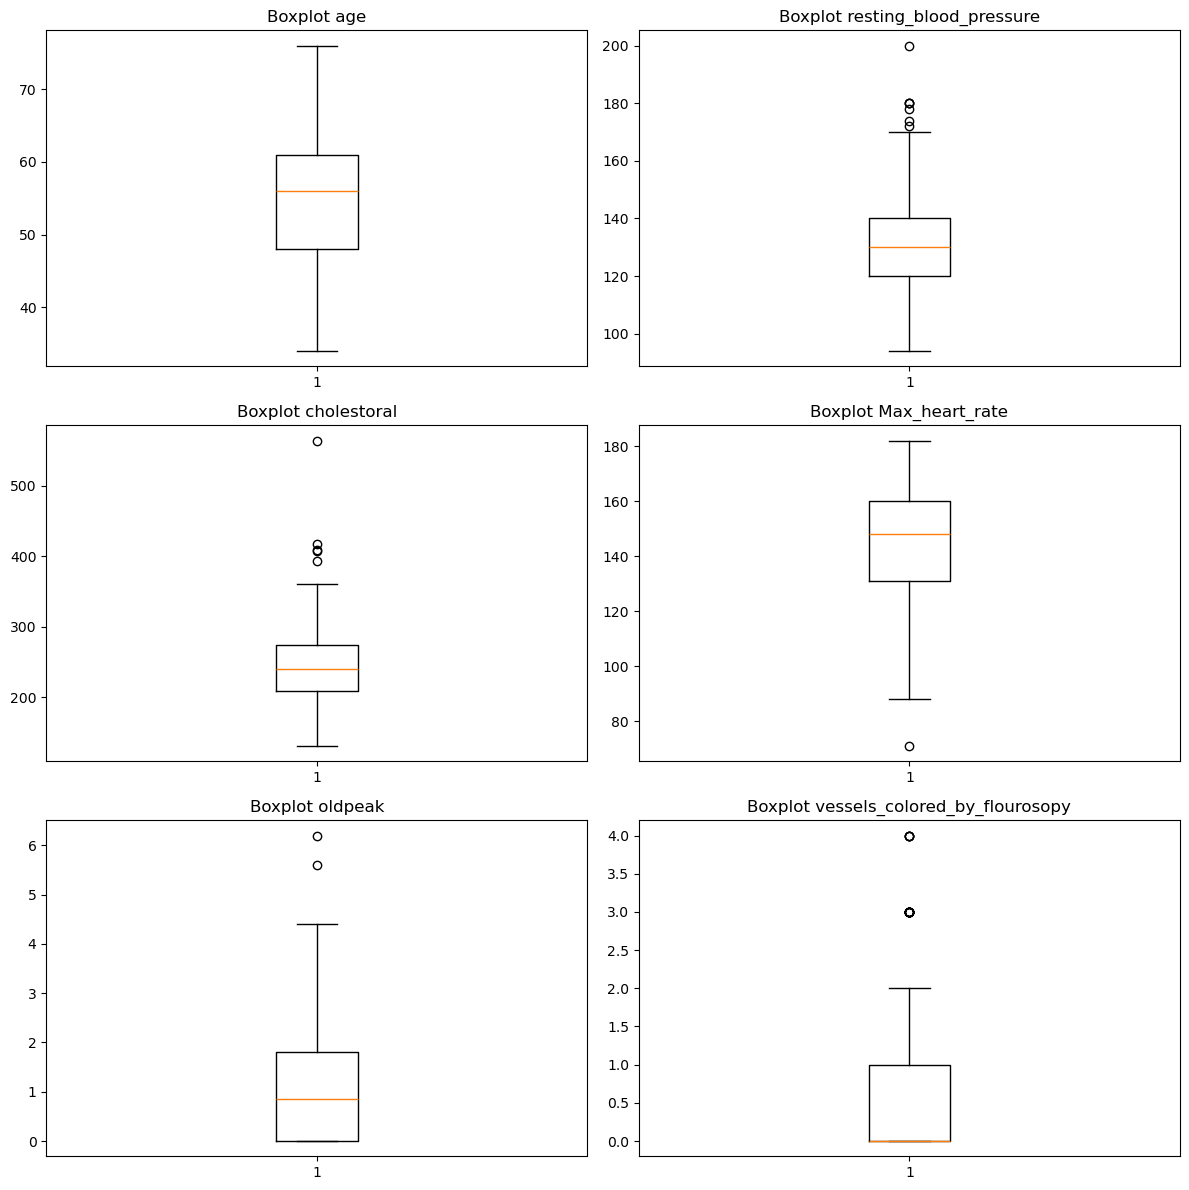

In [408]:
fig, axs = plt.subplots(3, 2, figsize=(12, 12))
axs = axs.flatten()

for i, ax in enumerate(axs):
    ax.boxplot(df_v4[num_col[i]])
    ax.set_title(f"Boxplot {num_col[i]}")

plt.tight_layout()
plt.show()

In [409]:
df_v5.describe()

,age,resting_blood_pressure,cholestoral,Max_heart_rate,oldpeak,vessels_colored_by_flourosopy,target
count,254.000000,254.000000,254.000000,254.000000,254.000000,254.000000,254.000000
mean,54.736220,131.244094,246.031496,144.562992,1.132677,0.740157,0.515748
std,8.815484,17.856130,52.870628,20.852057,1.179701,1.019281,0.500739
min,34.000000,94.000000,131.000000,71.000000,0.000000,0.000000,0.000000
25%,48.000000,120.000000,209.500000,131.000000,0.000000,0.000000,0.000000
50%,56.000000,130.000000,239.500000,148.000000,0.850000,0.000000,1.000000
75%,61.000000,140.000000,274.000000,160.000000,1.800000,1.000000,1.000000
max,76.000000,200.000000,564.000000,182.000000,6.200000,4.000000,1.000000


<Axes: xlabel='target', ylabel='cholestoral'>

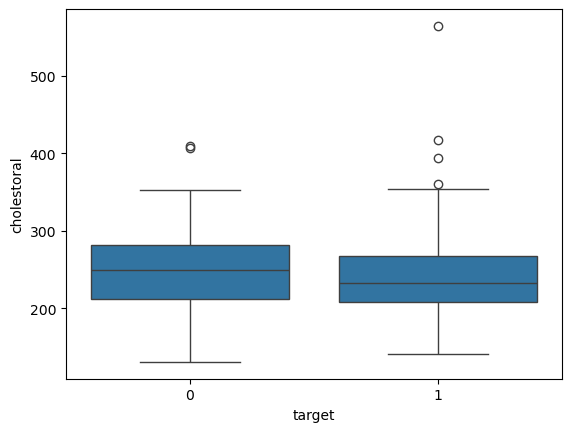

In [410]:
sns.boxplot(x="target", y="cholestoral", data=df_v5)

In [411]:
df_target = df_v5.groupby("target")[["resting_blood_pressure", "cholestoral"]].agg(["min", "max", "mean"])
df_target

resting_blood_pressure                  cholestoral                 
                          min  max        mean         min  max        mean
target                                                                     
0                         100  200  134.016260         131  409  249.512195
1                          94  180  128.641221         141  564  242.763359

<Axes: xlabel='target', ylabel='cholestoral'>

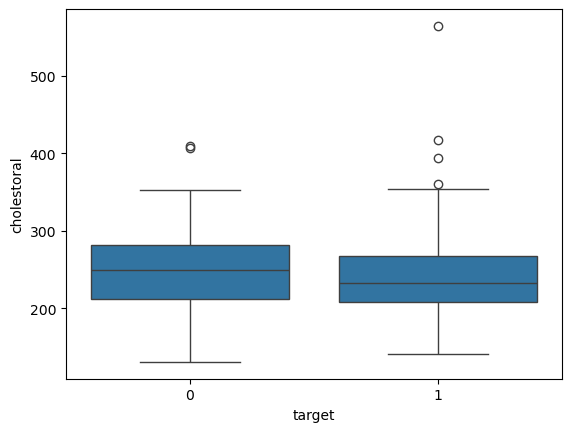

In [412]:
sns.boxplot(x="target", y="cholestoral", data=df_v5)

Si existen outliers pero estos están dentro de los límites clínicos posibles. Es decir, pueden existir pacientes que posean esos valores de colesterol, ritmo cardiaco, etc. Como se trata de un dataset de salud, área donde los enfermos (casasos raros o extremos) importan más que los sanos (casos normales) se decidió no eliminar los outliers.

### Normalización de datos

In [413]:
df_v6 = df_v5.copy()
df_v6.info()

<class 'pandas.core.frame.DataFrame'>
Index: 254 entries, 0 to 878
Data columns (total 14 columns):
 #   Column                         Non-Null Count  Dtype   
---  ------                         --------------  -----   
 0   age                            254 non-null    int64   
 1   sex                            254 non-null    category
 2   chest_pain_type                254 non-null    category
 3   resting_blood_pressure         254 non-null    int64   
 4   cholestoral                    254 non-null    int64   
 5   fasting_blood_sugar            254 non-null    category
 6   rest_ecg                       254 non-null    category
 7   Max_heart_rate                 254 non-null    int64   
 8   exercise_induced_angina        254 non-null    category
 9   oldpeak                        254 non-null    float64 
 10  slope                          254 non-null    category
 11  vessels_colored_by_flourosopy  254 non-null    int64   
 12  thalassemia                    254 non-nu

In [414]:
scaler = StandardScaler()

In [415]:
cols_a_escalar = ["age", "resting_blood_pressure", "cholestoral", "Max_heart_rate", "oldpeak"]
df_v6[cols_a_escalar] = scaler.fit_transform(df_v6[cols_a_escalar])
df_v6.head()

,age,sex,chest_pain_type,resting_blood_pressure,cholestoral,fasting_blood_sugar,rest_ecg,Max_heart_rate,exercise_induced_angina,oldpeak,slope,vessels_colored_by_flourosopy,thalassemia,target
0,-0.311001,Male,Typical angina,-0.350380,-0.644946,Lower than 120 mg/ml,ST-T wave abnormality,1.126185,No,-0.112689,Downsloping,2,Reversable Defect,0
1,-0.197340,Male,Typical angina,0.491327,-0.815509,Greater than 120 mg/ml,Normal,0.501515,Yes,1.670938,Upsloping,0,Reversable Defect,0
2,1.734892,Male,Typical angina,0.771895,-1.365100,Lower than 120 mg/ml,ST-T wave abnormality,-0.940033,Yes,1.246265,Upsloping,0,Reversable Defect,0
3,0.711946,Male,Typical angina,0.940237,-0.815509,Lower than 120 mg/ml,ST-T wave abnormality,0.789824,No,-0.962035,Downsloping,1,Reversable Defect,0
4,0.825606,Female,Typical angina,0.379099,0.909072,Greater than 120 mg/ml,ST-T wave abnormality,-1.853013,No,0.651723,Flat,3,Fixed Defect,0


### Codificación de variables categóricas

In [416]:
df_v7 = df_v6.copy()

In [417]:
fastig_blood_map = {"Lower than 120 mg/ml": 0, "Greater than 120 mg/ml": 1}
df_v7["fasting_blood_sugar"] = df_v7["fasting_blood_sugar"].map(fastig_blood_map)

In [418]:
nominal_cols = ["sex", "chest_pain_type", "rest_ecg", "exercise_induced_angina", "slope", "thalassemia"]

In [419]:
df_v7 = pd.get_dummies(df_v7, columns=nominal_cols, drop_first=True)
df_v7.head()

,age,resting_blood_pressure,cholestoral,fasting_blood_sugar,Max_heart_rate,oldpeak,vessels_colored_by_flourosopy,target,sex_Male,chest_pain_type_Atypical angina,chest_pain_type_Non-anginal pain,chest_pain_type_Typical angina,rest_ecg_Normal,rest_ecg_ST-T wave abnormality,exercise_induced_angina_Yes,slope_Flat,slope_Upsloping,thalassemia_Normal,thalassemia_Reversable Defect
0,-0.311001,-0.350380,-0.644946,0,1.126185,-0.112689,2,0,True,False,False,True,False,True,False,False,False,False,True
1,-0.197340,0.491327,-0.815509,1,0.501515,1.670938,0,0,True,False,False,True,True,False,True,False,True,False,True
2,1.734892,0.771895,-1.365100,0,-0.940033,1.246265,0,0,True,False,False,True,False,True,True,False,True,False,True
3,0.711946,0.940237,-0.815509,0,0.789824,-0.962035,1,0,True,False,False,True,False,True,False,False,False,False,True
4,0.825606,0.379099,0.909072,1,-1.853013,0.651723,3,0,False,False,False,True,False,True,False,True,False,False,False
